Problem: We can not do a naive Singular value decomposition of the boudary operator $$ \Lambda_\gamma : H^{-1/2}(\partial\Omega) \rightarrow H^{1/2}(\partial\Omega) $$

This is because the decomposition needs us to take into account the scalar products of the domain & image of the operator.
It turns out that the SVD is:
$$ \Lambda_\gamma = M_{H^{-1/2}(\partial\Omega)} U^T \Sigma V M_{H^{1/2}(\partial\Omega)} $$
Which is why we went through the hassle of computing the required mass matrices for the fractional boundary spaces.

In [1]:
using Ferrite
using ModularEIT
using Images
using IterativeSolvers
using LinearAlgebra


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [2]:
σf = 1.0e-2 # how much noise is added to f
σg = 1.0e-2 # How much noise is added to g

0.01

In [3]:
img = load("../reconstructions/1096.jpg")
itp = interpolate_array_2D(Float64.(img))
n = 63 
grid = generate_grid(Quadrilateral, (n, n));
∂Ω = union(getfacetset.((grid,), ["left", "top", "right", "bottom"])...)
fe  = FerriteFESpace{RefQuadrilateral}(grid,2,3,∂Ω)
cond_vec = project_function_to_fem(fe, itp)
cond_vec .= min.(max.(cond_vec,1e-6),1.0)
G_full = real_fourier_basis(8)
rhs_dict = Dict()
Threads.@threads for i in 2:256
    M = make_boundary(G_full[:, i],64)
    itp = interpolate_array_2D(M)
    rhs_dict[i] = assemble_rhs_func(fe, itp)
end

In [4]:
K = assemble_L(fe, cond_vec)
K_fac = cholesky(K)
mode_dict = Dict{Int64,FerriteEITMode}()
mode_dict_no_noise = Dict{Int64,FerriteEITMode}()
@time begin
    Threads.@threads for i in 2:256
        mode_dict[i-1] = create_mode_from_g(fe, rhs_dict[i], K_fac, normalize =  true, σ_f = σf, σ_g= σg)
        mode_dict_no_noise[i-1] = create_mode_from_g(fe, rhs_dict[i], K_fac, normalize =  true)
    end
end

  1.058031 seconds (1.10 M allocations: 910.697 MiB, 25.67% gc time, 27.56% compilation time)


In [5]:
_,_, Hn12, H12 = assemble_boundary_matrices!(fe)

(sparse([1, 2, 3, 4, 5, 1, 2, 3, 4, 5  …  374, 500, 502, 503, 504, 374, 500, 502, 503, 504], [1, 1, 1, 1, 1, 2, 2, 2, 2, 2  …  503, 503, 503, 503, 503, 504, 504, 504, 504, 504], [0.00846560846560844, -0.0010582010582010544, -0.0010582010582010544, 0.0021164021164021074, 0.00211640211640211, -0.0010582010582010544, 0.00846560846560847, 0.0, 0.00211640211640211, 0.0  …  0.0021164021164021226, 0.0, 0.002116402116402125, 0.016931216931216988, 0.0, 0.0, 0.002116402116402125, 0.0021164021164021226, 0.0, 0.016931216931216988], 504, 504), sparse([1, 2, 3, 4, 5, 1, 2, 3, 4, 5  …  374, 500, 502, 503, 504, 374, 500, 502, 503, 504], [1, 1, 1, 1, 1, 2, 2, 2, 2, 2  …  503, 503, 503, 503, 503, 504, 504, 504, 504, 504], [222.60000000000088, 13.650000000000087, 13.650000000000059, -115.50000000000055, -115.50000000000041, 13.650000000000087, 226.8000000000007, -6.300000000000027, -81.90000000000032, 18.900000000000098  …  -81.89999999999979, 18.899999999999945, -115.49999999999991, 386.39999999999895, 

In [15]:
H12

504×504 Symmetric{Float64, Matrix{Float64}}:
  1.23384      -0.083902     -0.083902     …   9.25015e-17  -4.56041e-17
 -0.083902      1.31144      -0.0161238        1.54629e-16   1.26668e-17
 -0.083902     -0.0161238     1.31144         -8.3543e-17   -2.41255e-17
 -0.226306     -0.0743961     0.0659812       -1.43994e-16  -1.29178e-16
 -0.226306      0.0659812    -0.0743961       -7.69336e-17   6.29773e-17
 -0.00441946   -0.113864      9.93867e-5   …  -1.10432e-16   8.35728e-18
  0.0180074    -0.0488927    -0.000451889      1.08524e-17  -4.27197e-17
 -0.000425545  -0.00313222    6.81773e-6      -3.14651e-16  -5.40091e-17
  0.001516      0.0125316    -2.9927e-5        1.80817e-16  -1.21274e-17
 -4.63779e-5   -0.000304288   4.52647e-7      -1.77242e-17   1.79653e-17
  ⋮                                        ⋱                
  2.80797e-16  -1.51177e-16   1.8615e-17   …  -4.36093e-5    0.00123327
 -6.69816e-18  -9.82397e-18  -1.95485e-16      1.40343e-5   -0.000440389
 -1.31582e-16   1.4

Now we can attempt an SVD on the dictionaries

In [7]:
G = hcat([mode_dict[i].g for i in 1:255]...)
F = hcat([mode_dict[i].f for i in 1:255]...)

504×255 Matrix{Float64}:
  1034.23  -401.435    24.2836   289.716   …    1.35665     10.193
  1026.61  -400.834    16.586    290.61         1.52351     -6.55372
  1026.71  -402.013    16.8537   288.8          1.2105      -6.63258
  1030.43  -401.245    20.4352   289.992        1.50163     -0.462478
  1030.46  -401.571    20.5521   289.466        1.25036     -0.471402
  1019.25  -399.371     9.07863  292.564   …    0.993196     4.26423
  1022.91  -400.178    12.8129   291.501        1.16004     -0.806728
  1011.95  -397.23      1.41092  295.328        1.93851     -6.88243
  1015.65  -398.38      5.29217  293.87         1.62027     -1.88179
  1004.54  -394.501    -6.53688  298.582        0.684337     4.22174
     ⋮                                     ⋱              
 -3777.01  -488.491  3786.58     271.52    …  -33.6791    -364.577
 -3544.1   -503.963  3556.55     296.981       11.4161      15.5863
 -3993.79  -448.443  4003.58     199.018       20.1827     260.927
 -3871.13  -462.81   38

In [8]:
Λ = F * pinv(G)

504×504 Matrix{Float64}:
  3.88209   1.81471   1.81382   5.67973  …   -2.24904   -4.2327    -4.30585
  2.04499   2.79705   2.08021   4.85647      -2.24539   -4.22504   -4.29907
  2.04304   2.08486   2.80854   4.13119      -2.24539   -4.22452   -4.29841
  2.84033   2.42121   2.03902   5.26382      -2.24697   -4.22834   -4.30169
  2.84232   2.04115   2.42257   4.87906      -2.24706   -4.22837   -4.30182
  1.8811    1.70241   1.74033   3.57464  …   -2.24185   -4.21822   -4.29185
  1.87774   2.29686   1.92448   4.17805      -2.24335   -4.22153   -4.29514
  1.56798   1.68115   1.58125   3.25102      -2.23832   -4.21184   -4.28498
  1.72947   1.63528   1.64796   3.36002      -2.23998   -4.21497   -4.28848
  1.44698   1.42691   1.42102   2.87258      -2.23501   -4.2049    -4.27918
  ⋮                                      ⋱                        
 -1.79018  -1.78979  -1.71007  -3.58032  …   18.8348    40.194     45.3442
 -1.68272  -1.68199  -1.59074  -3.36502      17.4564    35.8503    37.910

In [9]:
norm(Λ * mode_dict[255].g - mode_dict[255].f, Inf)

4.661160346586257e-12

In [10]:
V,Σ, U =  svd(Λ)

SVD{Float64, Float64, Matrix{Float64}, Vector{Float64}}
U factor:
504×504 Matrix{Float64}:
 -0.0142125  0.000318871  -0.0302659  …   0.0304266     0.0457157
 -0.0141799  0.00031867   -0.0301343      0.0858485     0.0975988
 -0.0141771  0.000314492  -0.0301429      0.0226542    -0.0300091
 -0.0141956  0.00031903   -0.0302009     -0.0682097    -0.124085
 -0.0141947  0.000317278  -0.0302034     -0.0125271     0.0183019
 -0.0141493  0.000320744  -0.0299994  …   0.0624417     0.0238675
 -0.0141643  0.000319749  -0.0300677     -0.0755029    -0.039407
 -0.0141224  0.000326385  -0.0298592     -0.0167369    -0.0384935
 -0.0141362  0.000323156  -0.0299313     -0.0282564    -0.0114954
 -0.0140969  0.00033544   -0.0297098     -0.00575538    0.0323802
  ⋮                                   ⋱                
  0.147663   0.0476301     0.0169018  …   0.00768801   -0.0558359
  0.135402   0.0413389     0.0127459     -0.000792658   0.137628
  0.161201   0.054932      0.0227869     -0.00473975   -0.012294

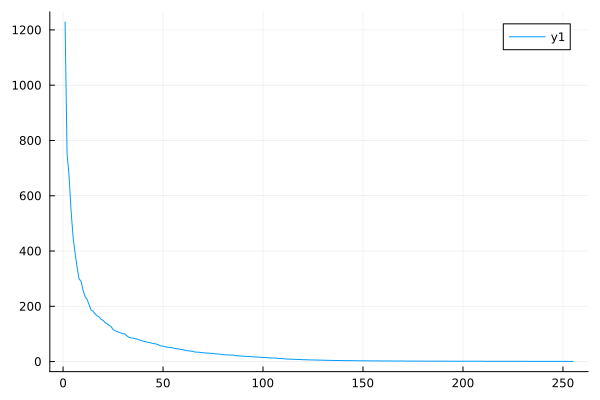

In [11]:
using Plots
#plot(Σ[1:255],yscale=:log10)
plot(Σ[1:255])

In [12]:
Vsq = sqrt(Hn12)*V

504×504 Matrix{Float64}:
 -0.000155302  3.48518e-6   -0.000330681  …  -3.10507e-5    5.79512e-5
 -0.000132681  2.98284e-6   -0.000281966      0.000313251   0.000375965
 -0.000132656  2.94517e-6   -0.000282044      6.94942e-5   -7.33459e-5
 -0.000239221  5.37422e-6   -0.000508934     -0.000602021  -0.00114807
 -0.000239205  5.34547e-6   -0.000508982     -0.000112931   0.000154132
 -0.000134429  3.04713e-6   -0.000285019  …   0.000229281   4.54411e-5
 -0.000221607  5.00342e-6   -0.000470412     -0.000640198  -0.000280876
 -0.000134139  3.09918e-6   -0.000283617     -0.000126545  -0.0002384
 -0.000221556  5.0676e-6    -0.000469102     -0.000256218  -0.000158487
 -0.00013389   3.18553e-6   -0.000282181     -7.96851e-5    1.53306e-5
  ⋮                                       ⋱                
  0.00139584   0.000448661   0.00015891   …   6.21882e-5   -4.51729e-5
  0.00213132   0.000652949   0.000203154     -1.50149e-6    0.00130727
  0.00153729   0.000525019   0.00021835       1.94064e-6   -

In [13]:
Usq = sqrt(H12)*U

504×504 Matrix{Float64}:
 -0.00644921  0.000255194  -0.0131665  …   0.00155073   0.00159296
 -0.00922333  0.000142366  -0.0191229     -0.0689529   -0.037065
 -0.00872627  0.000117203  -0.0192712      0.0133591   -0.0111461
 -0.0251475   0.000636807  -0.0519561      0.072992     0.0673218
 -0.0244278   0.000579616  -0.0521723     -0.0610719   -0.0668434
 -0.0086549   0.000395206  -0.0185333  …   0.0324844    0.0194403
 -0.0257352   0.000786689  -0.0541907      0.0337548   -0.0165308
 -0.00880188  0.000172207  -0.0184194      0.107315     0.0433896
 -0.0254854   0.000791858  -0.0538919     -0.0680852   -0.00618622
 -0.00863526  8.05672e-5   -0.0184867      0.099724     0.0738225
  ⋮                                    ⋱               
  0.0914075   0.0291807     0.0102899  …   0.0950042    0.0182739
  0.246239    0.0750744     0.0233193     -0.049559    -0.0255705
  0.0998087   0.0340223     0.0141141     -0.0337614    0.0242314
  0.279232    0.0923679     0.0357198     -0.0610767   -0.00

In [14]:
fe.down(K \ fe.up(g_new)) - f_new

UndefVarError: UndefVarError: `g_new` not defined in `Main`
Suggestion: check for spelling errors or missing imports.